# 03 - Callaway-Sant'Anna Staggered DiD

TWFE with staggered treatment timing can be biased (Goodman-Bacon 2021):
already-treated units get used as comparisons for later-treated ones, and
their own evolving effects enter with negative weight. Callaway &
Sant'Anna (2021) fix this by estimating a separate 2x2 DiD for every
(cohort, period) cell and only aggregating valid comparisons.

`src/methods/callaway_santanna.py` implements this directly on numpy - no
R, and no `did` package. Inference is a pairs cluster bootstrap over
states.


In [1]:
import sys
from pathlib import Path

# Walk up to the project root so the notebook runs from any working directory.
root = next(p for p in Path.cwd().resolve().parents if (p / "src").is_dir())
sys.path.insert(0, str(root))
# Data vintage: which raw inputs produced everything below. LAUS is
# revised, so an executed notebook has to carry its own provenance.
from src.data.manifest import format_manifest

print(format_manifest())


Data vintage recorded 2026-08-10T23:01:47+00:00
  BLS LAUS API v1, 2000-2022, measures unemployment_rate, labor_force
  Minimum wage source: Vaghul-Zipperer https://github.com/benzipperer/historicalminwage/releases/download/v1.4.0/mw_state_excel.zip
  bls_unemployment: d8a672e371b6... (110,329 bytes, modified 2026-08-10T22:58:45+00:00)
  user_minimum_wage_csv: absent
  vz_minimum_wage: 5176fbe0fe04... (1,022,044 bytes, modified 2026-07-26T01:22:57+00:00)


In [2]:
from src.data.loader import load_state_year_panel
from src.methods.callaway_santanna import estimate_att_gt

panel, is_synthetic = load_state_year_panel()
print(f"panel: {'synthetic' if is_synthetic else 'real'}, "
      f"{len(panel)} rows, {panel.state.nunique()} states, "
      f"{panel.year.min()}-{panel.year.max()}")

panel: real, 1173 rows, 51 states, 2000-2022


## Who is in the design

Never-treated states are the control group. States already above the
federal floor in the panel's first year have no clean pre-period and are
dropped.

In [3]:
never = panel[panel.adoption_year.isna()].state.nunique()
cohorts = (panel.dropna(subset=['adoption_year'])
           .drop_duplicates('state')
           .groupby('adoption_year').state.count())
first_year = int(panel.year.min())
always = int(cohorts.get(first_year, 0))

print(f'{never} never-treated (donors)')
print(f'{always} always-treated in {first_year} (no pre-period, dropped)')
print(f'{int(cohorts.sum()) - always} staggered adopters')
cohorts

15 never-treated (donors)
11 always-treated in 2000 (no pre-period, dropped)
25 staggered adopters


adoption_year
2000    11
2002     1
2004     1
2005     5
2006     4
2007    10
2009     1
2015     2
2021     1
Name: state, dtype: int64

## Group-time ATTs and their aggregations

In [4]:
result = estimate_att_gt(
    panel, aggregations=('simple', 'dynamic', 'group'), n_boot=500, seed=0
)
print(f"{result['n_units']} units in the design, "
      f"{result['n_boot']} bootstrap draws, "
      f"control group: {result['control_group']}")
if result['dropped_units']:
    print(f"dropped (no pre-period): {sorted(result['dropped_units'])}")

result['simple']

51 units in the design, 500 bootstrap draws, control group: nevertreated


,aggregation,att,se,ci_lower,ci_upper,band_lower,band_upper,n_cohorts,n_units
0,overall,0.556135,0.210144,0.144261,0.96801,0.143409,0.968862,8,25


The `simple` aggregation is the overall ATT: the average effect across
every treated state-year, in percentage points of unemployment.

In [5]:
result['group']  # one row per adoption cohort

,group,att,se,ci_lower,ci_upper,band_lower,band_upper,n_cohorts,n_units
0,2002.0,0.535714,0.159556,0.222990,0.848438,0.089545,0.981883,1,1
1,2004.0,0.187398,0.187923,-0.180924,0.555720,-0.338094,0.712889,1,1
2,2005.0,0.545833,0.333634,-0.108078,1.199744,-0.387113,1.478780,1,5
3,2006.0,1.174069,0.764972,-0.325249,2.673386,-0.965035,3.313172,1,4
4,2007.0,0.234740,0.239139,-0.233964,0.703443,-0.433968,0.903448,1,10
5,2009.0,1.660437,0.166151,1.334786,1.986087,1.195825,2.125048,1,1
6,2015.0,0.813819,0.243328,0.336906,1.290733,0.133398,1.494241,1,2
7,2021.0,-0.352500,0.169099,-0.683929,-0.021071,-0.825356,0.120356,1,1


## Event-study aggregation

Negative event times are pre-treatment placebo cells. Under parallel
trends they should sit near zero - this is the same check the TWFE event
study in notebook 02 performs, but built from comparisons that never use
an already-treated state as a control.

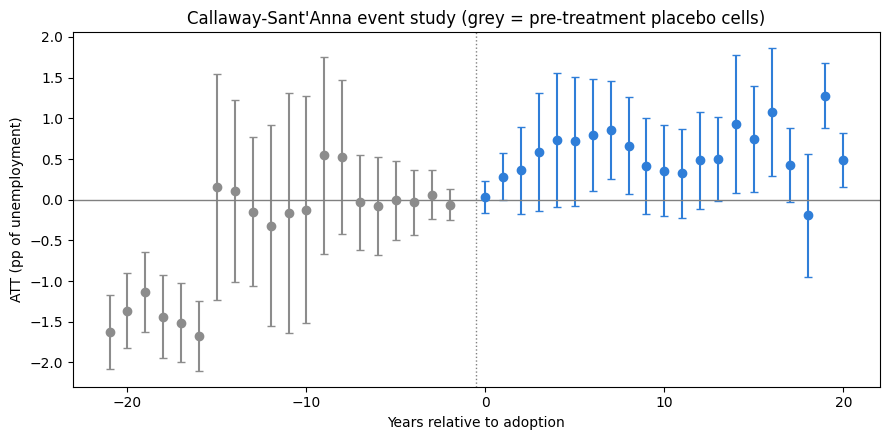

,event_time,att,se,ci_lower,ci_upper,band_lower,band_upper,n_cohorts,n_units
0,-21.0,-1.626667,0.234451,-2.086181,-1.167152,-2.342020,-0.911314,1,1
1,-20.0,-1.365556,0.233984,-1.824156,-0.906956,-2.079485,-0.651626,1,1
2,-19.0,-1.134444,0.251051,-1.626495,-0.642394,-1.900447,-0.368441,1,1
3,-18.0,-1.438889,0.260289,-1.949047,-0.928731,-2.233081,-0.644697,1,1
4,-17.0,-1.510000,0.247070,-1.994248,-1.025752,-2.263857,-0.756143,1,1
5,-16.0,-1.674444,0.217308,-2.100359,-1.248529,-2.337491,-1.011398,1,1
6,-15.0,0.153148,0.709881,-1.238193,1.544490,-2.012834,2.319131,2,3
7,-14.0,0.108519,0.571991,-1.012564,1.229601,-1.636736,1.853773,2,3
8,-13.0,-0.148519,0.466192,-1.062238,0.765201,-1.570959,1.273922,2,3
9,-12.0,-0.320000,0.629424,-1.553647,0.913647,-2.240491,1.600491,2,3


In [6]:
import matplotlib.pyplot as plt

event = result['dynamic']
fig, ax = plt.subplots(figsize=(9, 4.5))
pre = event[event.event_time < 0]
post = event[event.event_time >= 0]
for part, color in ((pre, '#8c8c8c'), (post, '#2f7ed8')):
    ax.errorbar(part.event_time, part.att,
                yerr=[part.att - part.ci_lower, part.ci_upper - part.att],
                fmt='o', capsize=3, color=color)
ax.axhline(0, color='gray', linewidth=1)
ax.axvline(-0.5, color='gray', linestyle=':', linewidth=1)
ax.set_xlabel('Years relative to adoption')
ax.set_ylabel('ATT (pp of unemployment)')
ax.set_title("Callaway-Sant'Anna event study (grey = pre-treatment placebo cells)")
plt.tight_layout()
plt.show()

event

## Comparison to naive TWFE

If the two diverge, staggered-timing bias matters for this panel. Note
they are not on the same scale as-is: TWFE here is a semi-elasticity
(per log point of minimum wage), while Callaway-Sant'Anna estimates a
binary-treatment effect. `src/methods/comparison.py` handles that
conversion; notebook 05 uses it.

In [7]:
from src.methods.comparison import treated_log_wage_gap
from src.methods.twfe_did import estimate_twfe

twfe = estimate_twfe(panel)
factor = treated_log_wage_gap(panel)
twfe_converted = twfe.params['log_minimum_wage'] * factor
cs_att = result['simple'].att.iloc[0]

print(f'mean treated log wage gap:        {factor:.4f}')
print(f'TWFE semi-elasticity:             {twfe.params["log_minimum_wage"]:+.4f}')
print(f'TWFE, converted to pp:            {twfe_converted:+.4f}')
print(f"Callaway-Sant'Anna overall ATT:   {cs_att:+.4f}")
print(f'difference:                       {cs_att - twfe_converted:+.4f} pp')

mean treated log wage gap:        0.1782
TWFE semi-elasticity:             +0.5755
TWFE, converted to pp:            +0.1026
Callaway-Sant'Anna overall ATT:   +0.5561
difference:                       +0.4536 pp
